# Model 3 — Integration

In [1]:
import os, json, warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr, pearsonr

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


> **LLM note:** The following cell was generated with Claude assistance (Level 3 skeleton).
> Cleaned up and restructed by Claude and GitHub Copilot.

In [ ]:
#Data source
DATA_MODE       = 'bsm2'                       # 'bsm2' | 'real'
DATA_PATH_BSM2  = 'DATA/BSM2_extracted_data.csv'
DATA_PATH_REAL  = ''
LABELS_PATH     = ''    
TIMESTAMP_COL   = 'timestamp'
TIMESTAMP_FMT   = '%Y-%m-%d %H:%M:%S'
RESOLUTION_MIN  = 15                           # 15 for BSM2, 10 for real
N_ROWS          = None                         # None = use all rows

# Variables (target + features)
TARGET_VARS  = ['S_PO4_e']
FEATURE_VARS = [
    'Q_in', 'Temp_in', 'S_PO4_in', 'S_NH4_in', 'S_F_in', 'S_A_in',
    'X_S_in', 'X_TSS_in',
    'S_PO4_r1', 'X_PAO_r1', 'X_PP_r1', 'S_A_r1',
    'S_O2_r5', 'S_PO4_r5', 'S_NH4_r5',
    'S_O2_r7', 'S_PO4_r7', 'X_TSS_r7',
]

# Combined list
ALL_VARS    = TARGET_VARS + [v for v in FEATURE_VARS if v not in TARGET_VARS]
N_VARS      = len(ALL_VARS)
N_TARGETS   = len(TARGET_VARS)
TARGET_IDX  = list(range(N_TARGETS))

# Window length
INPUT_HOURS    = 12
HORIZON_HOURS  = 6                             
INPUT_STEPS    = int(INPUT_HOURS   * 60 / RESOLUTION_MIN)
HORIZON_STEPS  = int(HORIZON_HOURS * 60 / RESOLUTION_MIN)
STRIDE         = INPUT_STEPS // 4

# Splits
TRAIN_RATIO = 0.75; VAL_RATIO = 0.10           # test = for integration

# Data path
DATA_PATH = DATA_PATH_BSM2 if DATA_MODE == 'bsm2' else DATA_PATH_REAL


# Model 3 specific
FORECASTER_NAME = 'LSTM'                       # LSTM, GRU, Transformer

# Uncertainty sampling
N_UNCERTAINTY_SAMPLES = 30

# Output directory
RESULTS_DIR = f'RESULTS/{DATA_MODE}'
os.makedirs(RESULTS_DIR, exist_ok=True)

FC_PATH  = f'CHECKPOINTS/forecaster_{FORECASTER_NAME}_{DATA_MODE}.pt'
VAE_PATH = f'CHECKPOINTS/vae_{DATA_MODE}.pt'
print(f'Loading:\n  {FC_PATH}\n  {VAE_PATH}')
print(f'Outputs → {RESULTS_DIR}/')

Loading:
  CHECKPOINTS/forecaster_LSTM_bsm2.pt
  CHECKPOINTS/vae_bsm2.pt
Outputs → RESULTS/bsm2/


> **LLM note:** The following cell was generated with Claude assistance (Level 4 substantial).
> Drafted by Claude, adapted by me, cleaned up and restructed by Claude.

In [ ]:
# LOAD CHECKPOINTS + RESTORE SCALERS

ckpt_fc  = torch.load(FC_PATH,  map_location=DEVICE, weights_only=False)
ckpt_vae = torch.load(VAE_PATH, map_location=DEVICE, weights_only=False)
cfg_fc, cfg_vae = ckpt_fc['config'], ckpt_vae['config']

assert cfg_fc['INPUT_STEPS'] == cfg_vae['WINDOW_STEPS'], (
    f'window mismatch: forecaster {cfg_fc["INPUT_STEPS"]} ≠ vae {cfg_vae["WINDOW_STEPS"]}')
assert cfg_fc['ALL_VARS'] == cfg_vae['ALL_VARS'], (
    'variable list mismatch between forecaster and VAE')

print(f'Forecaster ({cfg_fc["name"]}): input={cfg_fc["INPUT_STEPS"]} '
      f'horizon={cfg_fc["HORIZON_STEPS"]}  hidden={cfg_fc["HIDDEN_SIZE"]}')
print(f'VAE: window={cfg_vae["WINDOW_STEPS"]} hidden={cfg_vae["HIDDEN_SIZE"]} '
      f'latent={cfg_vae["LATENT_DIM"]}')

def restore_scaler(ckpt):
    if ckpt['scaler_type'] == 'MinMaxScaler':
        sc = MinMaxScaler()
        sc.data_min_   = np.array(ckpt['scaler_min'])
        sc.data_range_ = np.array(ckpt['scaler_range'])
        sc.scale_      = 1.0 / sc.data_range_
        sc.min_        = -sc.data_min_ * sc.scale_
        sc.n_features_in_ = len(sc.data_min_)
        return sc
    sc = StandardScaler()
    sc.mean_  = np.array(ckpt['scaler_mean'])
    sc.scale_ = np.array(ckpt['scaler_scale'])
    sc.var_   = sc.scale_ ** 2
    sc.n_features_in_ = len(sc.mean_)
    return sc

scaler_fc  = restore_scaler(ckpt_fc)
scaler_vae = restore_scaler(ckpt_vae)
print(f'Scalers restored: fc={ckpt_fc["scaler_type"]}, vae={ckpt_vae["scaler_type"]}')

Forecaster (LSTM): input=48 horizon=24  hidden=128
VAE: window=48 hidden=192 latent=24
Scalers restored: fc=MinMaxScaler, vae=StandardScaler


> **LLM note:** The following cell was generated with Claude assistance (Level 4 substantial).
> Drafted by Claude, adapted by me, cleaned up and restructed by Claude.

In [ ]:
# RECONSTRUCT MODEL ARCHITECTURES + LOAD WEIGHTS

class _RNNForecaster(nn.Module):
    def __init__(self, rnn_cls, n_in, h, nl, horizon, n_tgt, dropout=0.0):
        super().__init__()
        self.horizon, self.n_tgt = horizon, n_tgt
        self.enc = rnn_cls(n_in, h, nl, batch_first=True, bidirectional=True,
                           dropout=dropout if nl > 1 else 0)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(h * 2, horizon * n_tgt)
    def forward(self, x):
        out, _ = self.enc(x)
        return self.head(self.drop(out[:, -1, :])).view(-1, self.horizon, self.n_tgt)

class LSTMForecaster(_RNNForecaster):
    def __init__(self, *a, **kw): super().__init__(nn.LSTM, *a, **kw)
class GRUForecaster(_RNNForecaster):
    def __init__(self, *a, **kw): super().__init__(nn.GRU,  *a, **kw)

class TransformerForecaster(nn.Module):
    def __init__(self, n_in, h, nl, nh, horizon, n_tgt, dropout=0.0, max_len=2048):
        super().__init__()
        self.horizon, self.n_tgt = horizon, n_tgt
        self.input_proj = nn.Linear(n_in, h)
        self.pos_emb    = nn.Parameter(torch.randn(1, max_len, h) * 0.02)
        layer = nn.TransformerEncoderLayer(d_model=h, nhead=nh, dim_feedforward=h*4,
                                            dropout=dropout, batch_first=True,
                                            activation='gelu')
        self.enc = nn.TransformerEncoder(layer, num_layers=nl)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(h, horizon * n_tgt)
    def forward(self, x):
        h = self.input_proj(x) + self.pos_emb[:, :x.size(1)]
        h = self.enc(h)
        return self.head(self.drop(h.mean(dim=1))).view(-1, self.horizon, self.n_tgt)

def build_forecaster(c):
    args = (c['N_VARS'], c['HIDDEN_SIZE'], c['NUM_LAYERS'],
            c['HORIZON_STEPS'], c['N_TARGETS'], c['DROPOUT'])
    if c['name'] == 'LSTM':        return LSTMForecaster(*args)
    if c['name'] == 'GRU':         return GRUForecaster(*args)
    if c['name'] == 'Transformer':
        return TransformerForecaster(c['N_VARS'], c['HIDDEN_SIZE'], c['NUM_LAYERS'],
                                     c['NUM_HEADS'], c['HORIZON_STEPS'],
                                     c['N_TARGETS'], c['DROPOUT'])

class SeqVAE(nn.Module):
    def __init__(self, n_vars, h, latent, nl, L, dropout=0.0):
        super().__init__()
        self.H, self.D, self.L, self.V, self.NL = h, latent, L, n_vars, nl
        self.enc = nn.LSTM(n_vars, h, nl, batch_first=True, bidirectional=True,
                           dropout=dropout if nl > 1 else 0)
        self.mu_head     = nn.Linear(h * 4, latent)
        self.logvar_head = nn.Linear(h * 4, latent)
        self.pos_emb = nn.Parameter(torch.randn(1, L, h) * 0.02)
        self.z_proj  = nn.Linear(latent, h)
        self.dec = nn.LSTM(h * 2, h, nl, batch_first=True,
                           dropout=dropout if nl > 1 else 0)
        self.out  = nn.Linear(h, n_vars)
        self.drop = nn.Dropout(dropout)
    def encode(self, x):
        h, _ = self.enc(x)
        pooled = torch.cat([h.mean(dim=1), h[:, -1]], dim=1)
        return self.mu_head(pooled), self.logvar_head(pooled)
    def reparameterize(self, mu, lv):
        return mu + torch.exp(0.5*lv) * torch.randn_like(mu)
    def decode(self, z):
        B = z.size(0)
        z_proj = self.z_proj(z).unsqueeze(1).expand(-1, self.L, -1)
        pos    = self.pos_emb.expand(B, -1, -1)
        h, _   = self.dec(torch.cat([z_proj, pos], dim=2))
        return self.out(h)
    def forward(self, x):
        mu, lv = self.encode(x); z = self.reparameterize(mu, lv)
        return self.decode(z), mu, lv

forecaster = build_forecaster(cfg_fc)
forecaster.load_state_dict(ckpt_fc['state_dict']); forecaster.to(DEVICE).eval()

vae = SeqVAE(len(cfg_vae['ALL_VARS']), cfg_vae['HIDDEN_SIZE'],
             cfg_vae['LATENT_DIM'], cfg_vae['NUM_LAYERS'],
             cfg_vae['WINDOW_STEPS'], cfg_vae['DROPOUT'])
vae.load_state_dict(ckpt_vae['state_dict']); vae.to(DEVICE).eval()

print(f'Forecaster: {sum(p.numel() for p in forecaster.parameters()):,} params')
print(f'VAE:        {sum(p.numel() for p in vae.parameters()):,} params')

Forecaster: 158,744 params
VAE:        825,667 params


> **LLM note:** The following cell was generated with Claude assistance (Level 4 substantial).
> Drafted by Claude, adapted by me, cleaned up and restructed by Claude.

In [ ]:
# LOAD DATA + BUILD ALIGNED TEST WINDOWS

df = pd.read_csv(DATA_PATH)
df['timestamp'] = pd.to_datetime(df[TIMESTAMP_COL], format=TIMESTAMP_FMT)
df = df.sort_values('timestamp').set_index('timestamp')
if N_ROWS: df = df.iloc[:N_ROWS].copy()
df_model = df[ALL_VARS].copy()
for c in ALL_VARS:
    df_model[c] = df_model[c].interpolate('linear', limit_direction='both').ffill().bfill()

n = len(df_model)
train_end = int(n * TRAIN_RATIO)
val_end   = int(n * (TRAIN_RATIO + VAL_RATIO))

fc_scaled  = scaler_fc .transform(df_model.values)
vae_scaled = scaler_vae.transform(df_model.values)

X_fc, X_vae, Y_fut = [], [], []
i = val_end
H = cfg_fc['HORIZON_STEPS']; L = cfg_fc['INPUT_STEPS']
while i + L + H <= n:
    X_fc .append(fc_scaled [i : i + L])
    X_vae.append(vae_scaled[i : i + L])
    Y_fut.append(fc_scaled [i + L : i + L + H, TARGET_IDX])
    i += L

X_fc  = np.array(X_fc)
X_vae = np.array(X_vae)
Y_fut = np.array(Y_fut)

ts_now = df_model.index[val_end + L - 1::L][:len(X_fc)]

print(f'Aligned test windows: {len(X_fc)}')
print(f'  past window:  {L} steps  ({L * RESOLUTION_MIN / 60:.1f} h)')
print(f'  future horizon: {H} steps  ({H * RESOLUTION_MIN / 60:.1f} h)')

Aligned test windows: 108
  past window:  48 steps  (12.0 h)
  future horizon: 24 steps  (6.0 h)


> **LLM note:** The following cell was generated with Claude assistance (Level 4 substantial).
> Drafted by Claude, adapted by me, cleaned up and restructed by Claude.

In [ ]:
# RUN MODELS

def inv_scale_target(arr_scaled, scaler, n_vars, target_col=0):
    pad = np.zeros((len(arr_scaled), n_vars))
    pad[:, target_col] = arr_scaled
    return scaler.inverse_transform(pad)[:, target_col]

with torch.no_grad():
    Y_pred = forecaster(torch.FloatTensor(X_fc).to(DEVICE)).cpu().numpy()

@torch.no_grad()
def vae_scores(X, n_samples=4):
    vae.eval()
    Xt = torch.FloatTensor(X).to(DEVICE)
    stack = []
    for _ in range(n_samples):
        xh, _, _ = vae(Xt)
        stack.append(((xh - Xt) ** 2).cpu().numpy())
    return np.mean(np.stack(stack), axis=0)            

vae_err     = vae_scores(X_vae)
vae_score   = vae_err.max(axis=2).max(axis=1)          
vae_step_err= vae_err.max(axis=2)                      


target_name = TARGET_VARS[0]
fc_rmse = np.array([
    np.sqrt(mean_squared_error(
        inv_scale_target(Y_fut [i, :, 0], scaler_fc, cfg_fc['N_VARS']),
        inv_scale_target(Y_pred[i, :, 0], scaler_fc, cfg_fc['N_VARS'])
    )) for i in range(len(Y_fut))
])


last_val = X_fc[:, -1, TARGET_IDX[0]]
persist_pred = np.broadcast_to(last_val[:, None, None], Y_pred.shape).copy()
persist_rmse = np.array([
    np.sqrt(mean_squared_error(
        inv_scale_target(Y_fut       [i, :, 0], scaler_fc, cfg_fc['N_VARS']),
        inv_scale_target(persist_pred[i, :, 0], scaler_fc, cfg_fc['N_VARS'])
    )) for i in range(len(Y_fut))
])

print(f'Forecast RMSE ({target_name}, orig units): '
      f'mean={fc_rmse.mean():.4f}  std={fc_rmse.std():.4f}')
print(f'Persistence RMSE:                          mean={persist_rmse.mean():.4f}')
print(f'VAE anomaly score:                         mean={vae_score.mean():.4f}  '
      f'std={vae_score.std():.4f}')

Forecast RMSE (S_PO4_e, orig units): mean=0.1751  std=0.1515
Persistence RMSE:                          mean=0.8621
VAE anomaly score:                         mean=1.1463  std=0.9177


> **LLM note:** The following cell was generated with Claude assistance (Level 4 substantial).
> Drafted by Claude, for changing plot aestetics.

Pearson  r = +0.647  (p = 3.68e-14)
Spearman r = +0.492  (p = 6.27e-08)


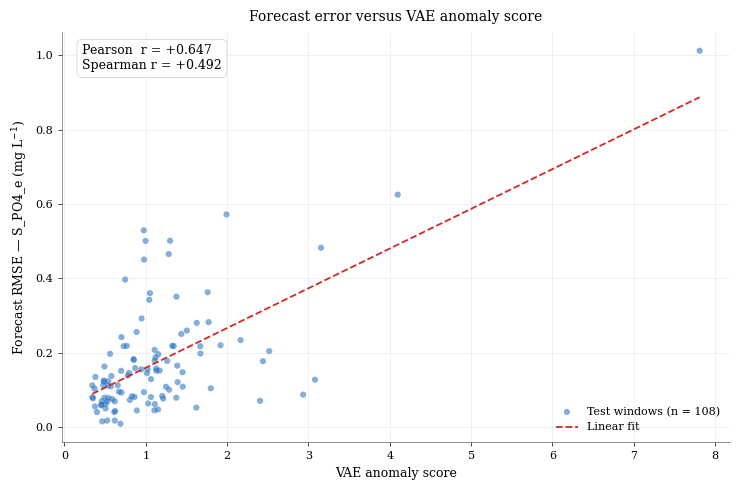

Saved → RESULTS/bsm2/1_score_correlation.png


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# SCORE CORRELATION — paste in MODEL_3_INTEGRATED, replacing the existing
# plotting block. Requires `vae_score`, `fc_rmse`, `target_name`,
# `RESULTS_DIR`, and scipy stats already imported.
# Saved to {RESULTS_DIR}/1_score_correlation.png.
# ══════════════════════════════════════════════════════════════════════
import os, numpy as np, matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Aesthetic helpers (matches M1/M2 plots) ──────────────────────────
plt.rcParams.update({
    'font.family':       'serif',
    'font.weight':       'light',
    'axes.titleweight':  'normal',
    'axes.labelweight':  'normal',
    'axes.titlesize':    10,
    'axes.labelsize':    9,
    'legend.fontsize':   8,
    'legend.frameon':    False,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
})

def style_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_linewidth(0.5)
        ax.spines[s].set_color('#666')
    ax.tick_params(width=0.5, length=3)
    ax.grid(alpha=0.25, lw=0.5)

# ── Correlations ─────────────────────────────────────────────────────
r_p, p_p = pearsonr (fc_rmse, vae_score)
r_s, p_s = spearmanr(fc_rmse, vae_score)
print(f'Pearson  r = {r_p:+.3f}  (p = {p_p:.2e})')
print(f'Spearman r = {r_s:+.3f}  (p = {p_s:.2e})')

# ─────────────────────────────────────────────────────────────────────
# FIGURE — scatter + linear fit
# ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7.5, 5))

ax.scatter(vae_score, fc_rmse,
           s=20, c='#1f6dbf', alpha=0.55, edgecolor='none',
           label=f'Test windows (n = {len(fc_rmse)})')

# Linear fit
m, b = np.polyfit(vae_score, fc_rmse, 1)
xline = np.array([vae_score.min(), vae_score.max()])
ax.plot(xline, m * xline + b,
        c='#d62728', lw=1.3, ls='--',
        label='Linear fit')

# Stats box (upper left)
stats_text = (f'Pearson  r = {r_p:+.3f}\n'
              f'Spearman r = {r_s:+.3f}')
ax.text(0.03, 0.97, stats_text,
        transform=ax.transAxes,
        fontsize=9, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='#cccccc',
                  boxstyle='round,pad=0.4', linewidth=0.5))

ax.set_xlabel('VAE anomaly score')
ax.set_ylabel(f'Forecast RMSE — {target_name} (mg L$^{{-1}}$)')
ax.set_title('Forecast error versus VAE anomaly score', pad=8)
ax.legend(loc='lower right')
style_axis(ax)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/1_score_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved → {RESULTS_DIR}/1_score_correlation.png')

> **LLM note:** The following cell was generated with Claude assistance (Level 4 substantial).
> Drafted by Claude, for changing plot aestetics.

Bin  Score range               n   Forecast RMSE    vs overall
────────────────────────────────────────────────────────────────
1    [0.34, 0.54]             21          0.0819        -53.2%
2    [0.54, 0.81]             22          0.1265        -27.8%
3    [0.83, 1.11]             21          0.2061         17.7%
4    [1.11, 1.39]             22          0.1819          3.9%
5    [1.44, 7.81]             22          0.2761         57.7%
────────────────────────────────────────────────────────────────
all                          108          0.1751

bottom 80% cleanest: RMSE = 0.1492  (-14.8% vs overall)
top    20% dirtiest: RMSE = 0.2761  (+57.7% vs overall)


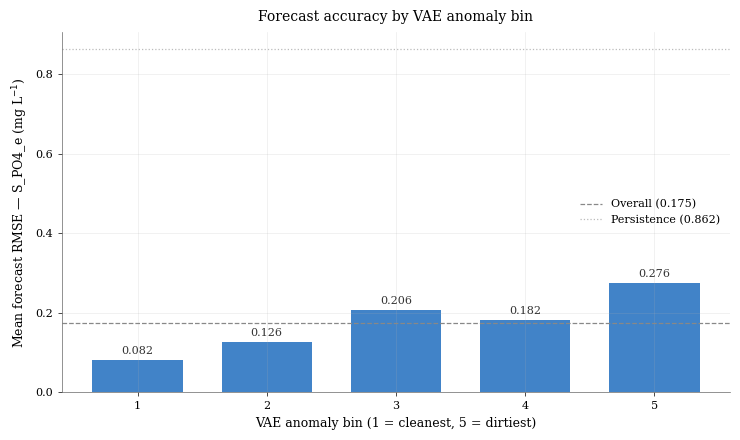

Saved → RESULTS/bsm2/2a_accuracy_by_bin.png


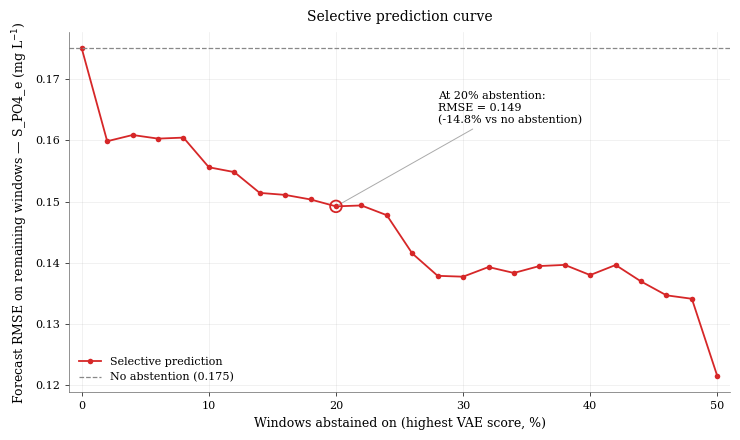

Saved → RESULTS/bsm2/2b_selective_prediction.png


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# CONDITIONAL FORECAST ACCURACY — paste in MODEL_3_INTEGRATED, replacing
# the existing plotting block. Produces TWO separate figures:
#   {RESULTS_DIR}/2a_accuracy_by_bin.png       — bar chart per quintile
#   {RESULTS_DIR}/2b_selective_prediction.png  — selective prediction curve
# Requires: `fc_rmse`, `vae_score`, `persist_rmse`, `target_name`, `RESULTS_DIR`.
# ══════════════════════════════════════════════════════════════════════
import os, numpy as np, matplotlib.pyplot as plt

os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Aesthetic helpers (matches M1/M2 plots) ──────────────────────────
plt.rcParams.update({
    'font.family':       'serif',
    'font.weight':       'light',
    'axes.titleweight':  'normal',
    'axes.labelweight':  'normal',
    'axes.titlesize':    10,
    'axes.labelsize':    9,
    'legend.fontsize':   8,
    'legend.frameon':    False,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
})

def style_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_linewidth(0.5)
        ax.spines[s].set_color('#666')
    ax.tick_params(width=0.5, length=3)
    ax.grid(alpha=0.25, lw=0.5)

C_BAR     = '#1f6dbf'
C_LINE    = '#d62728'
C_OVERALL = '#888888'
C_PERSIST = '#bbbbbb'

# ── Compute quintile statistics ──────────────────────────────────────
N = len(fc_rmse)
order = np.argsort(vae_score)
n_bins = 5
edges = np.linspace(0, N, n_bins + 1).astype(int)
overall = fc_rmse.mean()

print(f'{"Bin":<5s}{"Score range":<22s}{"n":>5s}{"Forecast RMSE":>16s}'
      f'{"vs overall":>14s}')
print('─' * 64)
rmse_bins, score_ranges = [], []
for b in range(n_bins):
    sel = order[edges[b]:edges[b+1]]
    rb  = fc_rmse[sel].mean()
    rmse_bins.append(rb)
    sr = f'[{vae_score[sel].min():.2f}, {vae_score[sel].max():.2f}]'
    score_ranges.append(sr)
    pct = (rb / overall - 1) * 100
    print(f'{b+1:<5d}{sr:<22s}{len(sel):>5d}{rb:>16.4f}{pct:>13.1f}%')
print('─' * 64)
print(f'{"all":<27s}{N:>5d}{overall:>16.4f}')

clean = order[:int(0.8 * N)]
dirty = order[int(0.8 * N):]
print(f'\nbottom 80% cleanest: RMSE = {fc_rmse[clean].mean():.4f}  '
      f'({(fc_rmse[clean].mean()/overall - 1)*100:+.1f}% vs overall)')
print(f'top    20% dirtiest: RMSE = {fc_rmse[dirty].mean():.4f}  '
      f'({(fc_rmse[dirty].mean()/overall - 1)*100:+.1f}% vs overall)')

# ─────────────────────────────────────────────────────────────────────
# FIGURE 1 — Forecast accuracy per bin
# ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7.5, 4.5))

bars = ax.bar(range(1, n_bins+1), rmse_bins,
              color=C_BAR, alpha=0.85, width=0.7,
              edgecolor='none')

# Reference lines
ax.axhline(overall, c=C_OVERALL, lw=0.9, ls='--',
           label=f'Overall ({overall:.3f})')
ax.axhline(persist_rmse.mean(), c=C_PERSIST, lw=0.9, ls=':',
           label=f'Persistence ({persist_rmse.mean():.3f})')

# Annotate bars with their values
for b, rb in zip(bars, rmse_bins):
    ax.text(b.get_x() + b.get_width()/2, rb + 0.01,
            f'{rb:.3f}', ha='center', va='bottom', fontsize=8, color='#333')

ax.set_xlabel('VAE anomaly bin (1 = cleanest, 5 = dirtiest)')
ax.set_ylabel(f'Mean forecast RMSE — {target_name} (mg L$^{{-1}}$)')
ax.set_title('Forecast accuracy by VAE anomaly bin', pad=8)
ax.set_xticks(range(1, n_bins+1))
ax.legend(loc='best')
style_axis(ax)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/2a_accuracy_by_bin.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {RESULTS_DIR}/2a_accuracy_by_bin.png')


# ─────────────────────────────────────────────────────────────────────
# FIGURE 2 — Selective prediction curve
# ─────────────────────────────────────────────────────────────────────
abstain = np.linspace(0, 0.5, 26)
rmse_kept = []
for f in abstain:
    keep = order[:max(int((1 - f) * N), 1)]
    rmse_kept.append(fc_rmse[keep].mean())
rmse_kept = np.array(rmse_kept)

fig, ax = plt.subplots(figsize=(7.5, 4.5))

ax.plot(abstain * 100, rmse_kept,
        c=C_LINE, lw=1.3, marker='o', ms=4, markeredgewidth=0,
        label='Selective prediction')
ax.axhline(overall, c=C_OVERALL, lw=0.9, ls='--',
           label=f'No abstention ({overall:.3f})')

# Highlight the 20% mark — your headline result
idx_20 = np.argmin(np.abs(abstain - 0.20))
rmse_at_20 = rmse_kept[idx_20]
pct_drop = (rmse_at_20 / overall - 1) * 100
ax.scatter([20], [rmse_at_20], s=70, facecolor='none',
           edgecolor=C_LINE, linewidth=1.3, zorder=5)
ax.annotate(f'At 20% abstention:\nRMSE = {rmse_at_20:.3f}\n({pct_drop:+.1f}% vs no abstention)',
            xy=(20, rmse_at_20),
            xytext=(28, rmse_at_20 + (overall - rmse_kept[-1]) * 0.3),
            fontsize=8, ha='left', va='center',
            arrowprops=dict(arrowstyle='-', color='#aaaaaa', lw=0.7))

ax.set_xlabel('Windows abstained on (highest VAE score, %)')
ax.set_ylabel(f'Forecast RMSE on remaining windows — {target_name} (mg L$^{{-1}}$)')
ax.set_title('Selective prediction curve', pad=8)
ax.set_xlim(-1, 51)
ax.legend(loc='lower left')
style_axis(ax)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/2b_selective_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {RESULTS_DIR}/2b_selective_prediction.png')

> **LLM note:** The following cell was generated with Claude assistance (Level 4 substantial).
> Drafted by Claude, adapted by me, cleaned up and restructed by Claude.

In [ ]:
# SUMMARY
summary = {
    'data_mode':                 DATA_MODE,
    'forecaster':                FORECASTER_NAME,
    'n_test_windows':            int(N),
    'forecast_RMSE_all':         float(fc_rmse.mean()),
    'forecast_RMSE_clean_80pct': float(fc_rmse[clean].mean()),
    'forecast_RMSE_dirty_20pct': float(fc_rmse[dirty].mean()),
    'persistence_RMSE':          float(persist_rmse.mean()),
    'vs_persistence_%':          float((1 - fc_rmse.mean() / persist_rmse.mean()) * 100),
    'pearson_r':                 float(r_p),
    'spearman_r':                float(r_s),
    'spearman_p':                float(p_s),
}
print('═' * 60)
print(f'INTEGRATION SUMMARY ({DATA_MODE})')
print('═' * 60)
for k, v in summary.items():
    print(f'  {k:<28s}  {v}')

with open(f'{RESULTS_DIR}/summary.json', 'w') as f: json.dump(summary, f, indent=2)
print(f'\nSaved → {RESULTS_DIR}/summary.json')
print(f'Plots → {RESULTS_DIR}/1_score_correlation.png, '
      f'2_conditional_accuracy.png, 3_predictive_intervals.png')

════════════════════════════════════════════════════════════
INTEGRATION SUMMARY (bsm2)
════════════════════════════════════════════════════════════
  data_mode                     bsm2
  forecaster                    LSTM
  n_test_windows                108
  forecast_RMSE_all             0.17505511516252092
  forecast_RMSE_clean_80pct     0.1492123745660829
  forecast_RMSE_dirty_20pct     0.2760767374940512
  persistence_RMSE              0.8621249054265028
  vs_persistence_%              79.6949242434982
  pearson_r                     0.6474446889425844
  spearman_r                    0.492259472024541
  spearman_p                    6.266857461002007e-08

Saved → RESULTS/bsm2/summary.json
Plots → RESULTS/bsm2/1_score_correlation.png, 2_conditional_accuracy.png, 3_predictive_intervals.png
